# Lesson 4 — Logistic Regression & SVM:

## Suggested exercises 

1. ~~Repeat the lecture without `StandardScaler` and compare all results()~~
2. For Logistic Regression, choose the threshold that maximizes **recall** instead of F1.
3. On `make_moons`, try a **denser grid of γ** values and watch the boundary overfit.
4. Add `class_weight="balanced"` and test what changes on **imbalanced** synthetic data.
5. Compare `LinearSVC` and `SVC(kernel="linear")` on **runtime and quality**.

## + Additional exercises

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_classification, make_moons
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC, SVC

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)

In [13]:
# visual from lecture 4
ink   = "#2f2a34"
paper = "#f6f1e7"
panel = "#efe4d6"
grid  = "#ccbda8"

sns.set_theme(
    context="talk", style="ticks",
    palette=["#ff6b6b", "#1982c4", "#ffd166", "#2a9d8f", "#6a4c93"],
    rc={
        "figure.facecolor": paper, "axes.facecolor": panel,
        "savefig.facecolor": paper, "axes.edgecolor": ink,
        "axes.labelcolor": ink, "text.color": ink,
        "xtick.color": ink, "ytick.color": ink,
        "grid.color": grid, "grid.linestyle": ":", "grid.alpha": 0.55,
        "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False,
        "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlepad": 14,
        "legend.frameon": True, "legend.facecolor": "#fbf7f0", "legend.edgecolor": grid,
    },
)

surface_cmap = sns.blend_palette(
    ["#1f2041", "#4b3f72", "#417b5a", "#f4d35e", "#ee964b"], as_cmap=True,
)
class_colors = ["#ff6b6b", "#1982c4", "#6a4c93", "#2a9d8f"]


def metric_frame(y_true, y_pred, y_score=None):
    rows = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        rows["roc_auc"] = roc_auc_score(y_true, y_score)
    return pd.DataFrame({"metric": list(rows.keys()), "value": list(rows.values())})


def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, n), np.linspace(x1_min, x1_max, n))
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]


def final_estimator(model):
    return model.named_steps["model"] if isinstance(model, Pipeline) else model


def scaler_step(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get("scaler")
    return None


def score_on_grid(model, grid):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(grid)[:, 1]
    scores = model.decision_function(grid)
    lo, hi = scores.min(), scores.max()
    return (scores - lo) / (hi - lo)


def plot_surface(ax, model, X, y, title, show_support=False, levels=28):
    xx, yy, g = make_grid(X)
    z = score_on_grid(model, g).reshape(xx.shape)
    ax.contourf(xx, yy, z, levels=levels, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors="#fffaf1", linewidths=2.2)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette=class_colors[:len(np.unique(y))],
                    s=60, edgecolor="#2b1d26", linewidth=0.4, legend=False, ax=ax)
    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        sc = scaler_step(model)
        if sc is not None:
            sv = sc.inverse_transform(sv)
        ax.scatter(sv[:, 0], sv[:, 1], s=220, facecolors="none",
                   edgecolors="#fffaf1", linewidths=1.8)
    ax.set_title(title); ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")


def plot_margin_surface(ax, model, X, y, title, show_support=True):
    xx, yy, g = make_grid(X)
    scores = model.decision_function(g).reshape(xx.shape)
    ax.contourf(xx, yy, scores, levels=28, cmap=surface_cmap, alpha=0.92)
    ax.contour(xx, yy, scores, levels=[-1, 0, 1],
               colors=["#f4d35e", "#fffaf1", "#4ecdc4"],
               linestyles=["--", "-", "--"], linewidths=[1.6, 2.3, 1.6])
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette=class_colors[:len(np.unique(y))],
                    s=60, edgecolor="#2b1d26", linewidth=0.4, legend=False, ax=ax)
    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        sc = scaler_step(model)
        if sc is not None:
            sv = sc.inverse_transform(sv)
        ax.scatter(sv[:, 0], sv[:, 1], s=220, facecolors="none",
                   edgecolors="#fffaf1", linewidths=1.8)
    ax.set_title(title); ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")


def annotate_bars(ax, offset=None, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim()
    delta = (ymax - ymin) * 0.02 if offset is None else offset
    for patch in ax.patches:
        value = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, value + delta,
                fmt.format(value), ha="center", va="bottom", fontsize=10)

In [14]:
X_breast, y_breast = load_breast_cancer(return_X_y=True)

X_lin, y_lin = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1,
    class_sep=1.8, random_state=42,
)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.25, stratify=y_lin, random_state=42,
)

logreg_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=4000)),
])
logreg_lin.fit(X_train_lin, y_train_lin)
proba_lin = logreg_lin.predict_proba(X_test_lin)[:, 1]


## Threshold that maximizes recall

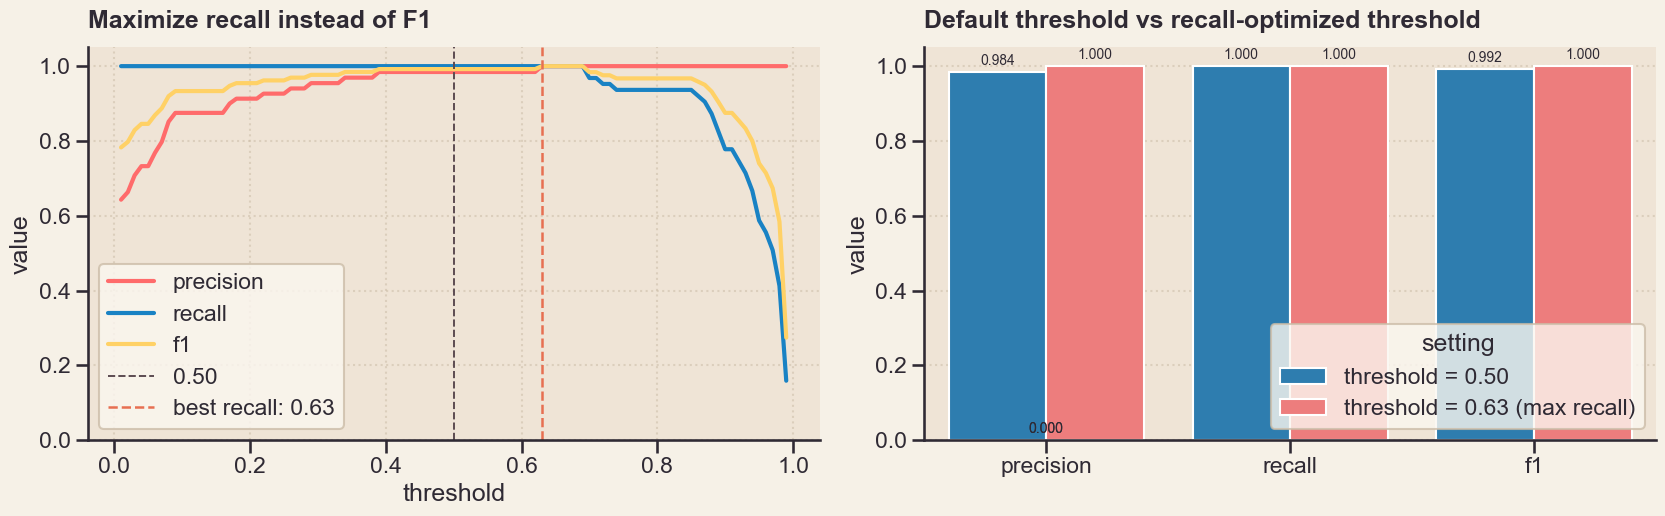

setting,threshold = 0.50,threshold = 0.63 (max recall)
metric,,
accuracy,0.992,1.0
f1,0.992,1.0
precision,0.984,1.0
recall,1.000,1.0
roc_auc,1.000,1.0


In [15]:
thresholds_recall = np.linspace(0.01, 0.99, 99)
recall_rows = []

for threshold in thresholds_recall:
    pred_t = (proba_lin >= threshold).astype(int)
    recall_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test_lin, pred_t, zero_division=0),
        "recall":    recall_score(y_test_lin, pred_t, zero_division=0),
        "f1":        f1_score(y_test_lin, pred_t, zero_division=0),
    })

recall_frame = pd.DataFrame(recall_rows)
best_recall_row = recall_frame.sort_values(
    ["recall", "precision", "f1"], ascending=[False, False, False]
).iloc[0]
best_threshold_recall = float(best_recall_row["threshold"])
pred_best_recall = (proba_lin >= best_threshold_recall).astype(int)

threshold_compare = pd.concat([
    metric_frame(y_test_lin, (proba_lin >= 0.5).astype(int), proba_lin
                ).assign(setting="threshold = 0.50"),
    metric_frame(y_test_lin, pred_best_recall, proba_lin
                ).assign(setting=f"threshold = {best_threshold_recall:.2f} (max recall)"),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

recall_plot = recall_frame.melt(id_vars="threshold", var_name="metric", value_name="value")
sns.lineplot(data=recall_plot, x="threshold", y="value", hue="metric",
             linewidth=3, ax=axes[0])
axes[0].axvline(0.5, color="#5c4b51", linestyle="--", linewidth=1.4, label="0.50")
axes[0].axvline(best_threshold_recall, color="#e76f51", linestyle="--",
                linewidth=1.8, label=f"best recall: {best_threshold_recall:.2f}")
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title("Maximize recall instead of F1")
axes[0].legend()

sns.barplot(
    data=threshold_compare.query("metric in ['precision', 'recall', 'f1']"),
    x="metric", y="value", hue="setting",
    palette=["#1982c4", "#ff6b6b"], ax=axes[1],
)
annotate_bars(axes[1], offset=0.01)
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title("Default threshold vs recall-optimized threshold")
axes[1].set_xlabel("")

fig.tight_layout()
plt.show()

threshold_compare.pivot(index="metric", columns="setting", values="value").round(3)

## Denser γ grid on make_moons

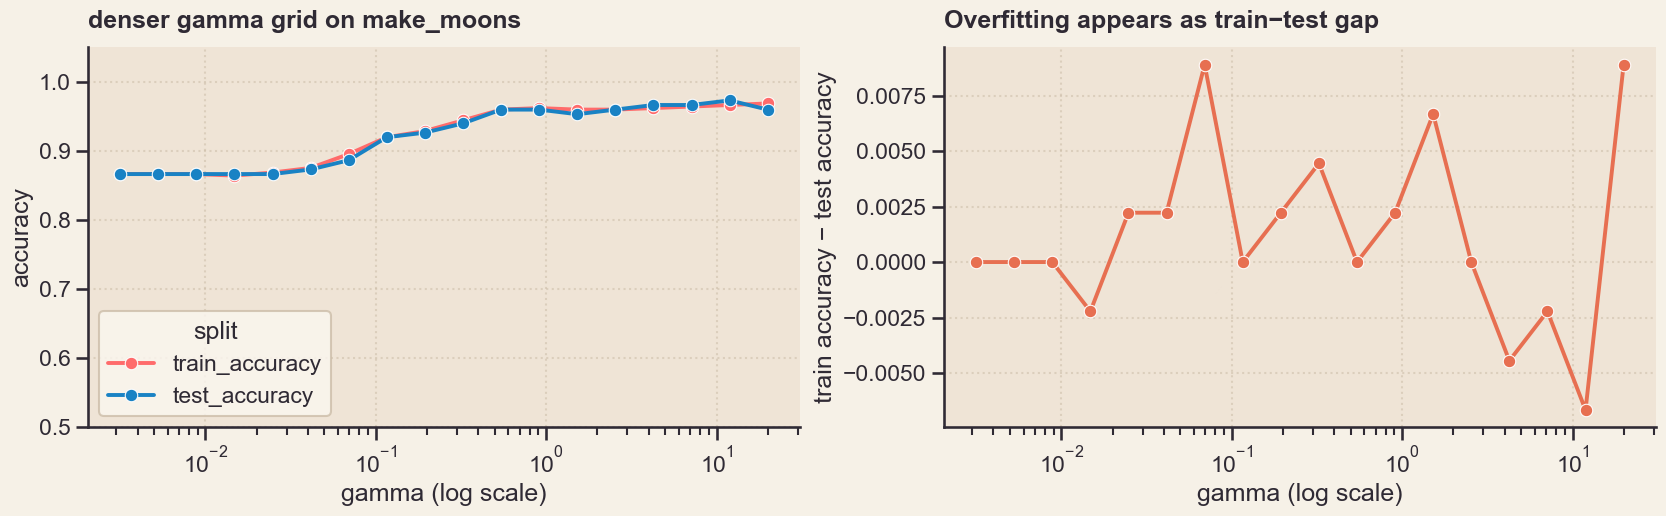

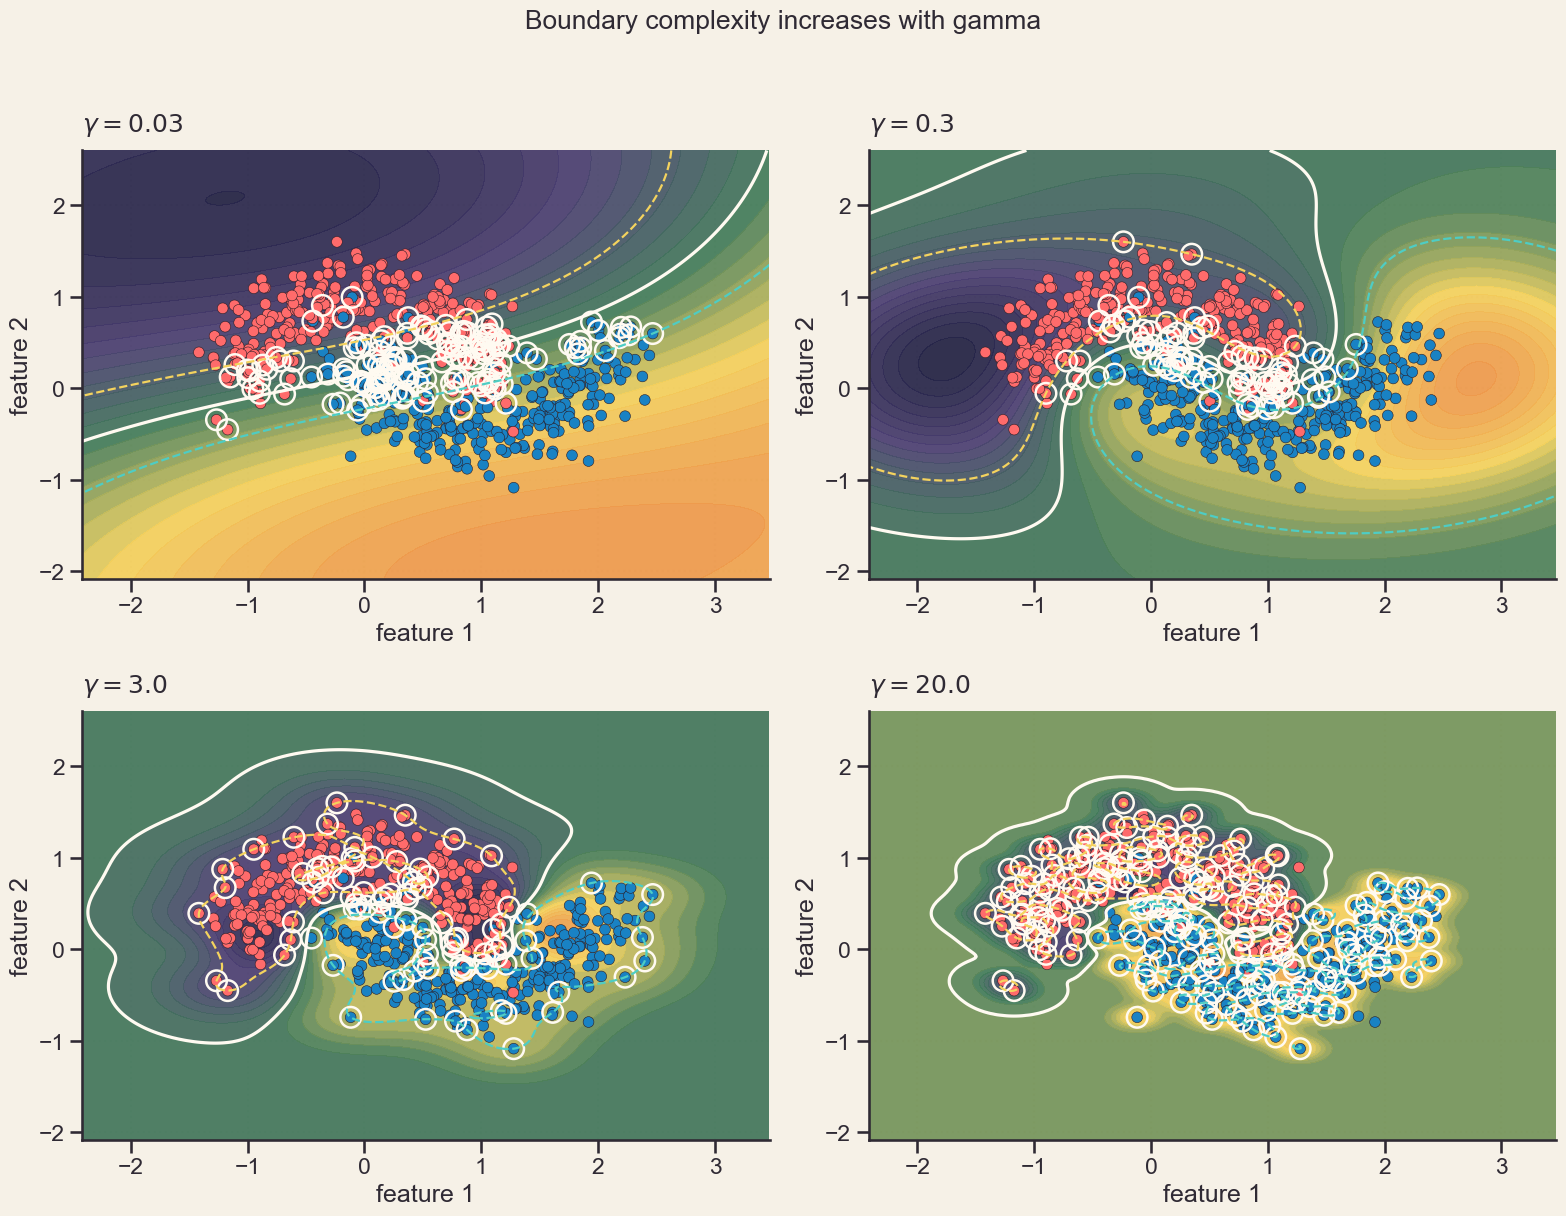

,gamma,train_accuracy,test_accuracy,generalization_gap
16,11.925,0.967,0.973,-0.007
15,7.128,0.964,0.967,-0.002
14,4.260,0.962,0.967,-0.004
17,19.953,0.969,0.960,0.009
10,0.544,0.960,0.960,0.000
13,2.546,0.960,0.960,0.000
11,0.910,0.962,0.960,0.002
12,1.522,0.960,0.953,0.007


In [16]:
X_moon_dense, y_moon_dense = make_moons(n_samples=600, noise=0.22, random_state=42)
X_train_dense, X_test_dense, y_train_dense, y_test_dense = train_test_split(
    X_moon_dense, y_moon_dense, test_size=0.25, stratify=y_moon_dense, random_state=42,
)

gamma_dense = np.logspace(-2.5, 1.3, 18)
dense_rows = []
for gamma in gamma_dense:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=5.0, gamma=gamma, probability=True, random_state=42)),
    ])
    model.fit(X_train_dense, y_train_dense)
    dense_rows.append({
        "gamma": gamma,
        "train_accuracy": accuracy_score(y_train_dense, model.predict(X_train_dense)),
        "test_accuracy":  accuracy_score(y_test_dense,  model.predict(X_test_dense)),
    })

dense_frame = pd.DataFrame(dense_rows)
dense_frame["generalization_gap"] = dense_frame["train_accuracy"] - dense_frame["test_accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
sns.lineplot(
    data=dense_frame.melt(id_vars="gamma",
                          value_vars=["train_accuracy", "test_accuracy"],
                          var_name="split", value_name="accuracy"),
    x="gamma", y="accuracy", hue="split", marker="o", linewidth=2.8, ax=axes[0],
)
axes[0].set_xscale("log"); axes[0].set_ylim(0.5, 1.05)
axes[0].set_title("denser gamma grid on make_moons")
axes[0].set_xlabel("gamma (log scale)")

sns.lineplot(data=dense_frame, x="gamma", y="generalization_gap",
             marker="o", color="#e76f51", linewidth=2.8, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Overfitting appears as train−test gap")
axes[1].set_xlabel("gamma (log scale)")
axes[1].set_ylabel("train accuracy − test accuracy")
fig.tight_layout(); plt.show()

# Decision boundary snapshots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, gamma in zip(axes.flat, [0.03, 0.3, 3.0, 20.0]):
    m = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=5.0, gamma=gamma, random_state=42)),
    ])
    m.fit(X_train_dense, y_train_dense)
    plot_margin_surface(ax, m, X_moon_dense, y_moon_dense, rf"$\gamma={gamma}$")
fig.suptitle("Boundary complexity increases with gamma", y=1.02, fontsize=19)
fig.tight_layout(); plt.show()

dense_frame.sort_values("test_accuracy", ascending=False).head(8).round(3)

## class_weight="balanced" on imbalanced data

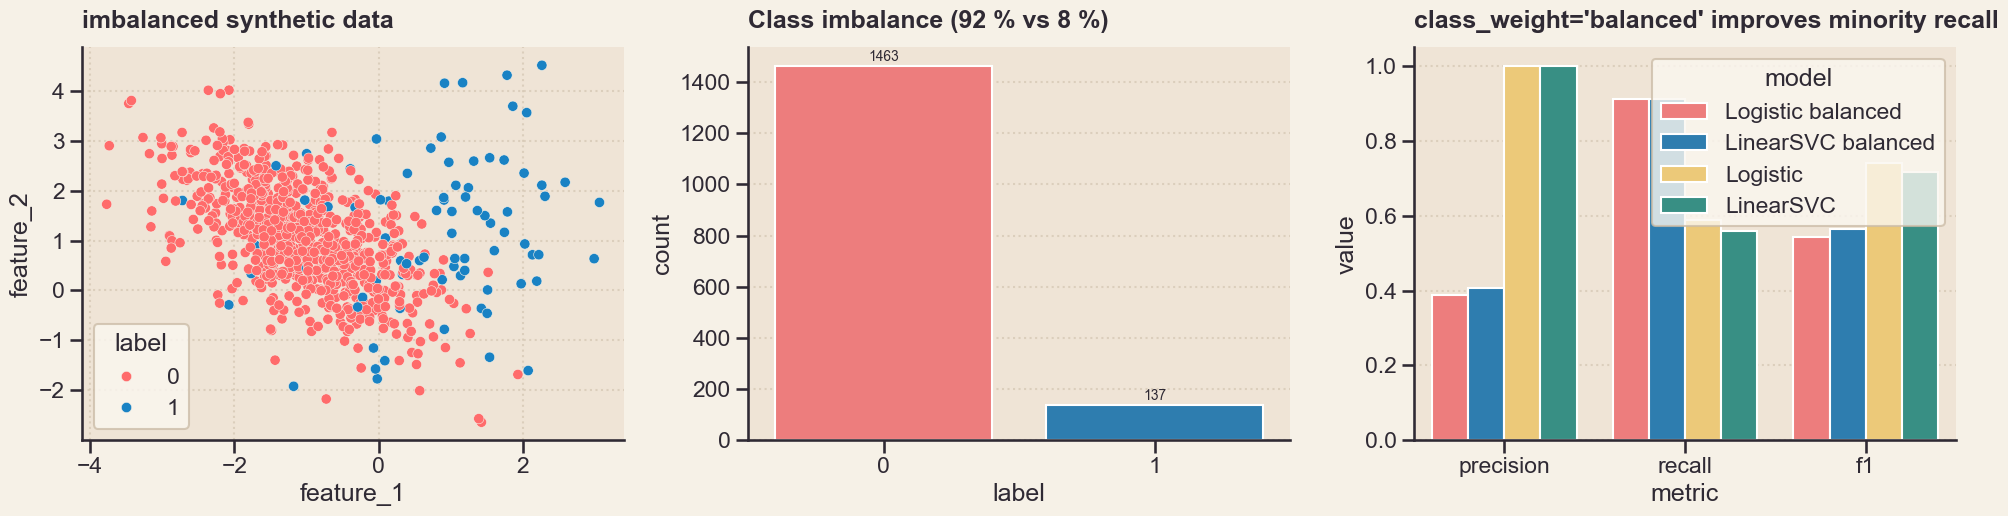

,model,accuracy,precision,recall,f1,roc_auc
1,Logistic balanced,0.870,0.388,0.912,0.544,0.933
3,LinearSVC balanced,0.880,0.408,0.912,0.564,0.934
0,Logistic,0.965,1.000,0.588,0.741,0.929
2,LinearSVC,0.962,1.000,0.559,0.717,0.927


In [ ]:
X_imb, y_imb = make_classification(
    n_samples=1600, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.1, weights=[0.92, 0.08],
    flip_y=0.01, random_state=42,
)
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.25, stratify=y_imb, random_state=42,
)

imbalance_frame = pd.DataFrame(X_imb, columns=["feature_1", "feature_2"])
imbalance_frame["label"] = y_imb
imbalance_counts = (
    imbalance_frame["label"].value_counts().sort_index()
    .rename_axis("label").reset_index(name="count")
)

imb_models = {
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000)),
    ]),
    "Logistic balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000, class_weight="balanced")),
    ]),
    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(C=1.0, max_iter=10000)),
    ]),
    "LinearSVC balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(C=1.0, max_iter=10000, class_weight="balanced")),
    ]),
}

imb_rows = []
for name, model in imb_models.items():
    model.fit(X_train_imb, y_train_imb)
    pred  = model.predict(X_test_imb)
    score = model.decision_function(X_test_imb)
    imb_rows.append({
        "model": name,
        "accuracy":  accuracy_score(y_test_imb, pred),
        "precision": precision_score(y_test_imb, pred, zero_division=0),
        "recall":    recall_score(y_test_imb, pred, zero_division=0),
        "f1":        f1_score(y_test_imb, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test_imb, score),
    })

imb_results = pd.DataFrame(imb_rows).sort_values("recall", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

sns.scatterplot(data=imbalance_frame.sample(900, random_state=42),
                x="feature_1", y="feature_2", hue="label",
                palette=class_colors[:2], s=55, edgecolor=paper,
                linewidth=0.4, ax=axes[0])
axes[0].set_title("imbalanced synthetic data")

sns.barplot(data=imbalance_counts, x="label", y="count",
            hue="label", palette=class_colors[:2],
            dodge=False, legend=False, ax=axes[1])
annotate_bars(axes[1], offset=10, fmt="{:.0f}")
axes[1].set_title("Class imbalance")

sns.barplot(
    data=imb_results.melt(id_vars="model",
                          value_vars=["precision", "recall", "f1"],
                          var_name="metric", value_name="value"),
    x="metric", y="value", hue="model", ax=axes[2],
)
axes[2].set_ylim(0.0, 1.05)
axes[2].set_title("class_weight='balanced' improves minority recall")

fig.tight_layout(); plt.show()

imb_results.round(3)

## LinearSVC vs SVC(kernel="linear") runtime & quality

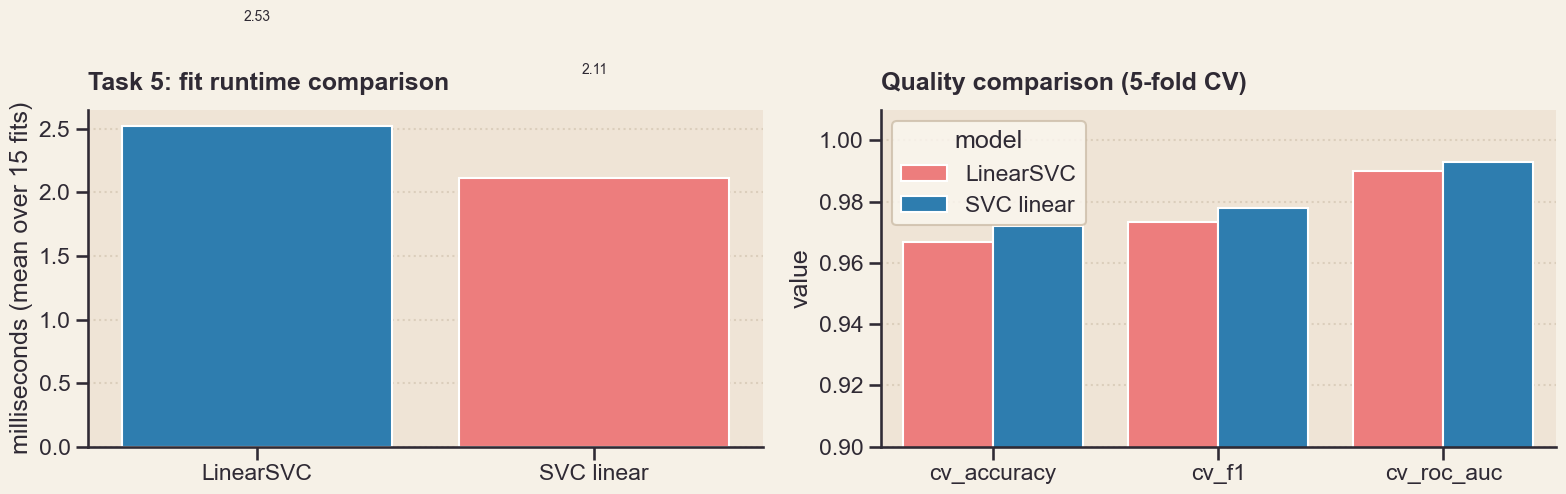

,model,fit_time_ms_mean,fit_time_ms_std,test_accuracy,test_f1,test_roc_auc,cv_accuracy,cv_f1,cv_roc_auc
0,LinearSVC,2.5255,1.0230,0.972,0.9780,0.9939,0.9667,0.9734,0.9901
1,SVC linear,2.1124,0.7199,0.986,0.9889,0.9973,0.9719,0.9779,0.9929


In [18]:
X_train_cmp, X_test_cmp, y_train_cmp, y_test_cmp = train_test_split(
    X_breast, y_breast, test_size=0.25, stratify=y_breast, random_state=42,
)

linear_runtime_models = {
    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(C=1.0, max_iter=12000)),
    ]),
    "SVC linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1.0)),
    ]),
}

runtime_rows = []
for name, model in linear_runtime_models.items():
    fit_times = []
    for _ in range(15):
        start = time.perf_counter()
        model.fit(X_train_cmp, y_train_cmp)
        fit_times.append((time.perf_counter() - start) * 1000)
    pred  = model.predict(X_test_cmp)
    score = model.decision_function(X_test_cmp)
    cv_scores = cross_validate(
        model, X_breast, y_breast, cv=5,
        scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}, n_jobs=-1,
    )
    runtime_rows.append({
        "model": name,
        "fit_time_ms_mean": np.mean(fit_times),
        "fit_time_ms_std":  np.std(fit_times),
        "test_accuracy":    accuracy_score(y_test_cmp, pred),
        "test_f1":          f1_score(y_test_cmp, pred),
        "test_roc_auc":     roc_auc_score(y_test_cmp, score),
        "cv_accuracy":      cv_scores["test_accuracy"].mean(),
        "cv_f1":            cv_scores["test_f1"].mean(),
        "cv_roc_auc":       cv_scores["test_roc_auc"].mean(),
    })

runtime_frame = pd.DataFrame(runtime_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.barplot(data=runtime_frame, x="model", y="fit_time_ms_mean",
            hue="model", palette=["#1982c4", "#ff6b6b"],
            dodge=False, legend=False, ax=axes[0])
annotate_bars(axes[0], offset=0.8, fmt="{:.2f}")
axes[0].set_title("Task 5: fit runtime comparison")
axes[0].set_ylabel("milliseconds (mean over 15 fits)")
axes[0].set_xlabel("")

quality_plot = runtime_frame.melt(
    id_vars="model", value_vars=["cv_accuracy", "cv_f1", "cv_roc_auc"],
    var_name="metric", value_name="value",
)
sns.barplot(data=quality_plot, x="metric", y="value", hue="model", ax=axes[1])
axes[1].set_ylim(0.9, 1.01)
axes[1].set_title("Quality comparison (5-fold CV)")
axes[1].set_xlabel("")

fig.tight_layout(); plt.show()

runtime_frame.round(4)


## Logistic Regression on Breast Cancer with ROC & PR curves

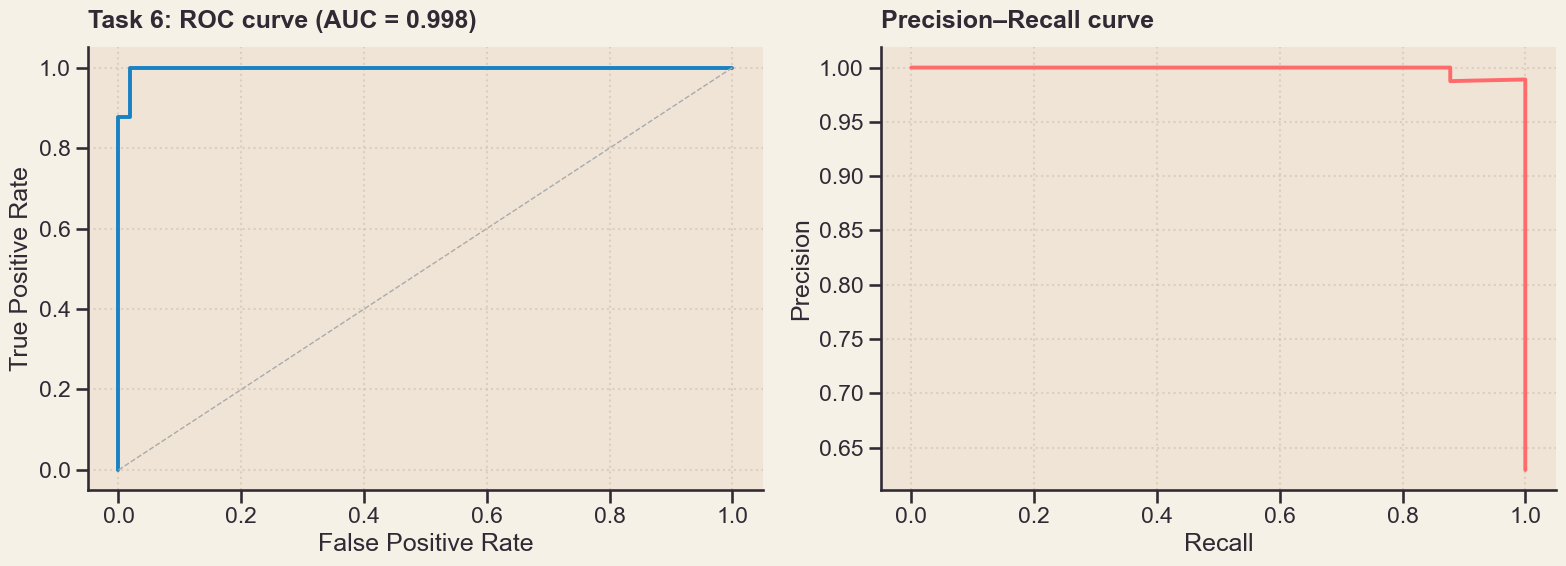

,metric,value
0,accuracy,0.986014
1,precision,0.988889
2,recall,0.988889
3,f1,0.988889
4,roc_auc,0.997694


In [ ]:
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(
    X_breast, y_breast, test_size=0.25, stratify=y_breast, random_state=42,
)

lr_bc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=4000)),
])
lr_bc.fit(X_tr_bc, y_tr_bc)
lr_bc_proba = lr_bc.predict_proba(X_te_bc)[:, 1]
lr_bc_pred  = lr_bc.predict(X_te_bc)

fpr, tpr, _ = roc_curve(y_te_bc, lr_bc_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_te_bc, lr_bc_proba)
auc_val = roc_auc_score(y_te_bc, lr_bc_proba)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, linewidth=2.8, color="#1982c4")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#aaa", linewidth=1)
axes[0].set_title(f"ROC curve AUC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[1].plot(rec_curve, prec_curve, linewidth=2.8, color="#ff6b6b")
axes[1].set_title("Precision–Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

fig.tight_layout(); plt.show()

metric_frame(y_te_bc, lr_bc_pred, lr_bc_proba)

## SVM RBF on Breast Cancer + GridSearchCV

In [9]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42)),
])

param_grid = {
    "model__C":     [0.1, 1.0, 10.0, 100.0],
    "model__gamma": ["scale", 0.01, 0.1, 1.0],
}

grid_search = GridSearchCV(
    svm_pipe, param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="f1", n_jobs=-1, refit=True,
)
grid_search.fit(X_tr_bc, y_tr_bc)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV F1: {grid_search.best_score_:.4f}")

svm_bc_pred  = grid_search.predict(X_te_bc)
svm_bc_proba = grid_search.predict_proba(X_te_bc)[:, 1]

metric_frame(y_te_bc, svm_bc_pred, svm_bc_proba)

Best parameters: {'model__C': 10.0, 'model__gamma': 0.01}
Best CV F1: 0.9780


,metric,value
0,accuracy,0.979021
1,precision,0.988764
2,recall,0.977778
3,f1,0.983240
4,roc_auc,0.998742


## Confusion matrices: Logistic Regression vs SVM on Breast Cancer

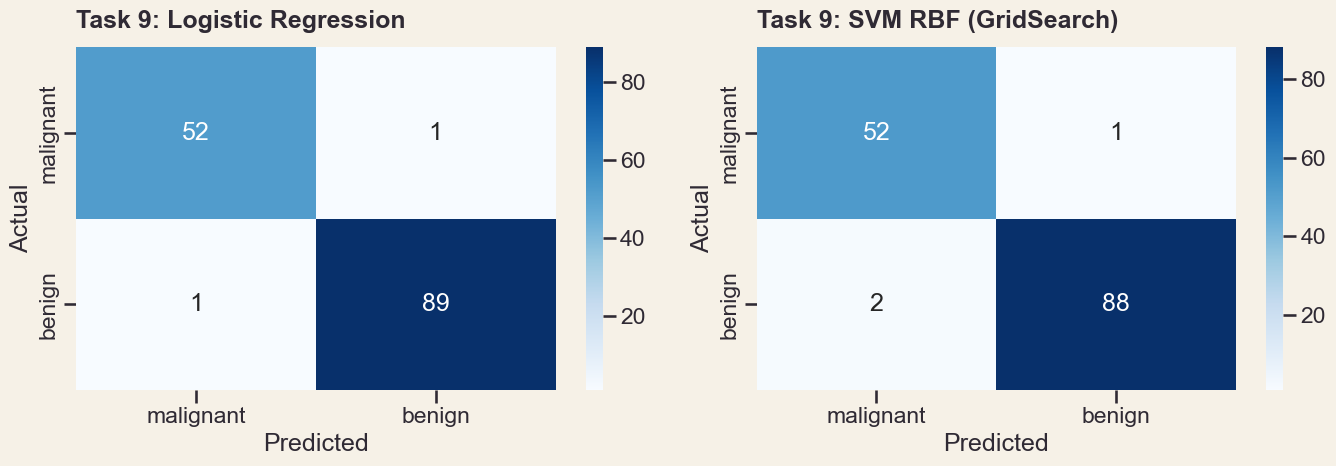

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", lr_bc_pred),
    ("SVM RBF (GridSearch)", svm_bc_pred),
]):
    cm = confusion_matrix(y_te_bc, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["malignant", "benign"],
                yticklabels=["malignant", "benign"], ax=ax)
    ax.set_title(f"Task 9: {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

fig.tight_layout(); plt.show()